# Лабораторная работа 10 (часть 1)

## Цель
Построить **прогноз на 4 года** методом ARIMA

**Что такое ARIMA**

ARIMA — это аббревиатура: AR (авторегрессия) + I (интегрирование) + MA (скользящее среднее). Параметры записываются как ARIMA(p, d, q)

**AR(p)** — авторегрессия. Идея: текущее значение ряда зависит от его прошлых значений. Например, AR(2) означает, что сегодняшнее значение это взвешенная сумма двух предыдущих плюс случайный шум

**MA(q)** — скользящее среднее. Здесь текущее значение зависит не от прошлых значений ряда, а от прошлых ошибок прогноза. Т.е. как будто модель помнит насколько она ошиблась в прошлый раз и делает поправку

**I(d)** — интегрирование. Это просто количество раз, которое мы дифференцируем ряд, чтобы сделать его стационарным. d=1 означает, что мы работаем не с самим рядом, а с приростами

Для корректной работы ARIMA временной ряд должен быть стационарным.

Стационарный ряд обладает:
- постоянным средним,
- постоянной дисперсией,
- отсутствием выраженного тренда.

### Импорты

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [3]:
# загружаем листы
year_df = pd.read_excel('M3C.xls', sheet_name="M3Year")
quart_df = pd.read_excel('M3C.xls', sheet_name="M3Quart")
month_df = pd.read_excel('M3C.xls', sheet_name="M3Month")

## Годовой ряд

### Загрузка ряда

Длина ряда: 20, среднее: 4311.2, std: 1866.0


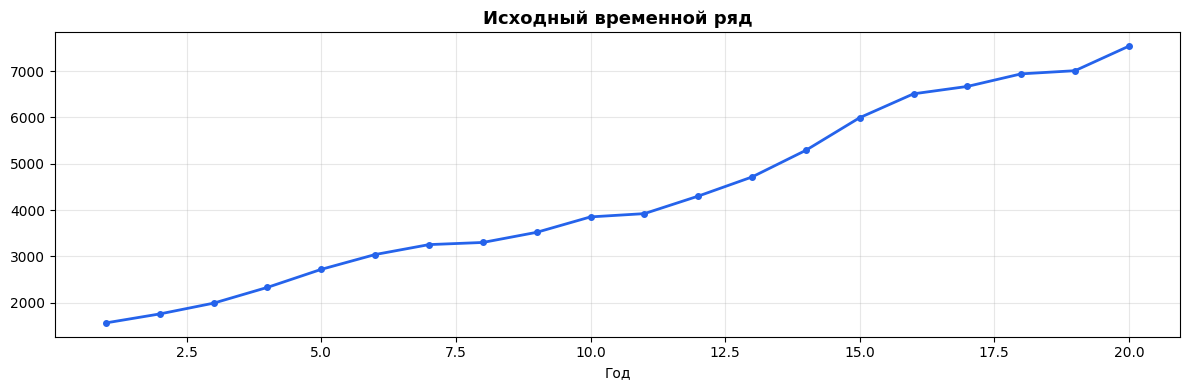

In [82]:
series = year_df.iloc[14, 6:].dropna().astype(float)
n = len(series)
print(f"Длина ряда: {n}, среднее: {np.mean(series):.1f}, std: {np.std(series):.1f}")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(1, n + 1), series, color='#2563eb', lw=2, marker='o', ms=4)
plt.title('Исходный временной ряд', fontsize=13, fontweight='bold')
plt.xlabel('Год')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Тест на стационарность

Для проверки стационарности используется тест Дики-Фуллера (ADF-test)

**H0:** ряд нестационарен

**H1:** ряд стационарен

----
если **p-value < 0.05** → отвергаем H0 → ряд считается стационарным  
если **p-value ≥ 0.05** → нет оснований отвергнуть H0 → ряд нестационарен 

In [83]:
adf_orig = adfuller(series)
print(f"ADF исходный ряд:    stat={adf_orig[0]:.3f}, p={adf_orig[1]:.4f}")


adf_diff1 = adfuller(np.diff(series, 1))
print(f"ADF 1-я разность:    stat={adf_diff1[0]:.3f}, p={adf_diff1[1]:.4f}")

adf_diff2 = adfuller(np.diff(series, 2))
print(f"ADF 2-я разность:    stat={adf_diff2[0]:.3f}, p={adf_diff2[1]:.4f}")



ADF исходный ряд:    stat=2.092, p=0.9988
ADF 1-я разность:    stat=-2.685, p=0.0766
ADF 2-я разность:    stat=-4.449, p=0.0002


Видно, что после 2 дифференцирования ряд становится стационарным, таким образом останавливаемся на параметре d = 3

In [84]:
series_diff1 = np.diff(series, n=2)

### ACF/PACF дифференцированного ряда

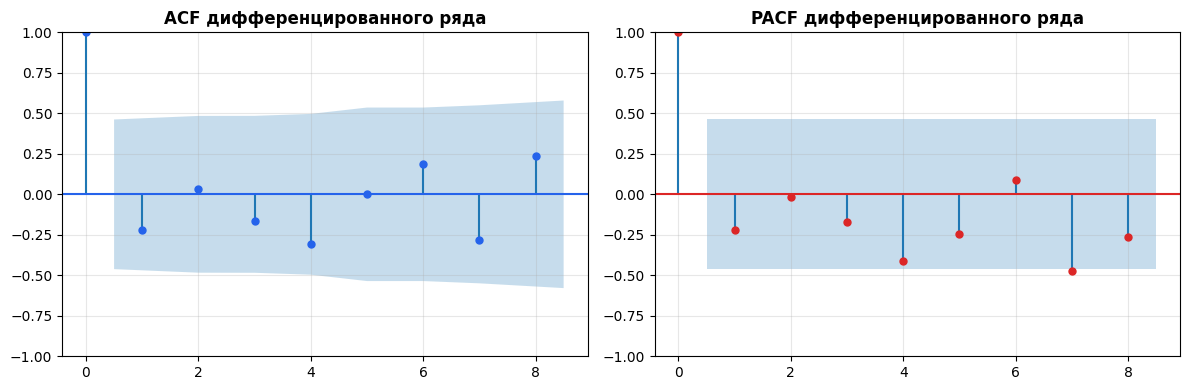

In [85]:
# ACF: если резко обрывается на лаге q → признак MA(q)
# PACF: если резко обрывается на лаге p → признак AR(p)

max_lags = min(10, len(series_diff1) // 2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series_diff1, lags=max_lags, ax=axes[0], color='#2563eb', alpha=0.05)
axes[0].set_title('ACF дифференцированного ряда', fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(series_diff1, lags=max_lags, ax=axes[1], color='#dc2626', alpha=0.05)
axes[1].set_title('PACF дифференцированного ряда', fontweight='bold')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### Подбор параметров

Исходя из теста на стационарность и графиков ACF и PACF можно предположить, что самая лучшая модель будет ARIMA (0,2,0). Однако, учитывая для повышения точности, проверим все близкие модели и выберем лучшую из них по метрике AIC:

- параметр интегрирования d = 2
- параметр авторегрессии p находится в диапазоне [0, 1]
- параметр скользящего среднего q находится в диапазоне [0, 1]

In [86]:
# AIC штрафует за сложность модели, BIC штрафует сильнее
results = []
for p in range(0, 2):
    for d in [2]:
        for q in range(0, 2):
            try:
                m = ARIMA(series, order=(p, d, q)).fit()
                results.append({'order': (p, d, q), 'aic': round(m.aic, 2),
                                 'bic': round(m.bic, 2)})
            except Exception:
                pass

results_df = pd.DataFrame(results).sort_values('aic')
print("Топ-5 моделей")
print(results_df.head(5).to_string(index=False))

Топ-5 моделей
    order    aic    bic
(1, 2, 1) 244.00 246.67
(0, 2, 0) 244.28 245.17
(0, 2, 1) 244.61 246.39
(1, 2, 0) 245.05 246.83


### Проверка остатков (тест Льюнга-Бокса)

Если p > 0.05 — остатки не автокоррелированы → модель адекватна

p для ARIMA(1, 2, 1): 0.4561


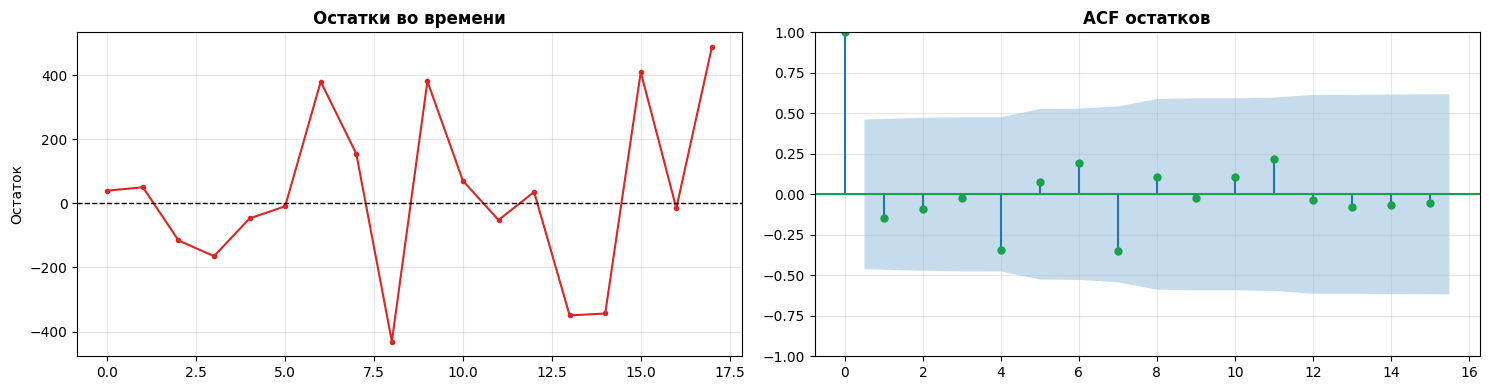

In [87]:
best_order = (1, 2, 1)

model_check = ARIMA(series_diff1, order=best_order).fit()
lb_test = acorr_ljungbox(model_check.resid, lags=[10], return_df=True)
print(f"p для ARIMA{best_order}: {lb_test['lb_pvalue'].values[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Остатки во времени
axes[0].plot(model_check.resid, color='#dc2626', lw=1.5, marker='o', ms=3)
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set_title('Остатки во времени', fontweight='bold')
axes[0].set_ylabel('Остаток')
axes[0].grid(True, alpha=0.3)

# ACF остатков
plot_acf(model_check.resid, lags=15, ax=axes[1], color='#16a34a', alpha=0.05)
axes[1].set_title('ACF остатков', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Тестирование прогноза

Откладываем последние 4 наблюдения как тест и смотрим на метрики

In [88]:
# train/test split
train, test = series[:-4], series[-4:]

# обучение модели
model_train = ARIMA(train, order=best_order).fit()

# прогноз на 4 шага
fc_test = model_train.forecast(steps=4)

# делаем одинаковые индексы
fc_test.index = test.index

# метрики
mape = np.mean(np.abs((test - fc_test) / test)) * 100
mae  = np.mean(np.abs(test - fc_test))
rmse = np.sqrt(mean_squared_error(test, fc_test))

# вывод
print("Тестирование (последние 4 года):")
print(f"Факт:\n{np.round(test, 1)}\n")
print(f"Прогноз:\n{np.round(fc_test, 1)}")

print("\nМетрики качества:")
print(f"MAPE: {mape:.2f}%")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Тестирование (последние 4 года):
Факт:
17    6670.0
18    6941.5
19    7010.0
20    7539.5
Name: 14, dtype: float64

Прогноз:
17    6992.1
18    7453.7
19    7903.5
20    8346.4
Name: predicted_mean, dtype: float64

Метрики качества:
MAPE: 8.91%
MAE:  633.69
RMSE: 673.72


### Финальный прогноз

In [89]:
# обучение на всём ряде
model_full = ARIMA(series, order=best_order).fit()

print("\nИтоговая модель:")
print(model_full.summary())

# прогноз
fc_obj = model_full.get_forecast(steps=4)

fc_future = fc_obj.predicted_mean
fc_ci = fc_obj.conf_int(alpha=0.05)

print("\nПрогноз на 4 года вперёд:")

for i in range(4):
    forecast = fc_future.iloc[i]
    lower = fc_ci.iloc[i, 0]
    upper = fc_ci.iloc[i, 1]

    print(
        f"  Год +{i+1}: "
        f"{forecast:.1f} "
        f"(95% ДИ: [{lower:.1f}, {upper:.1f}])"
    )


Итоговая модель:
                               SARIMAX Results                                
Dep. Variable:                     14   No. Observations:                   20
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -119.001
Date:                Thu, 21 May 2026   AIC                            244.001
Time:                        18:21:58   BIC                            246.672
Sample:                    01-01-1970   HQIC                           244.369
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4058      0.266      1.525      0.127      -0.116       0.927
ma.L1         -0.9968      6.370     -0.156      0.876     -13.483      11.489
sigma2      2.907e+04   1.79e+05  

### Визуализация

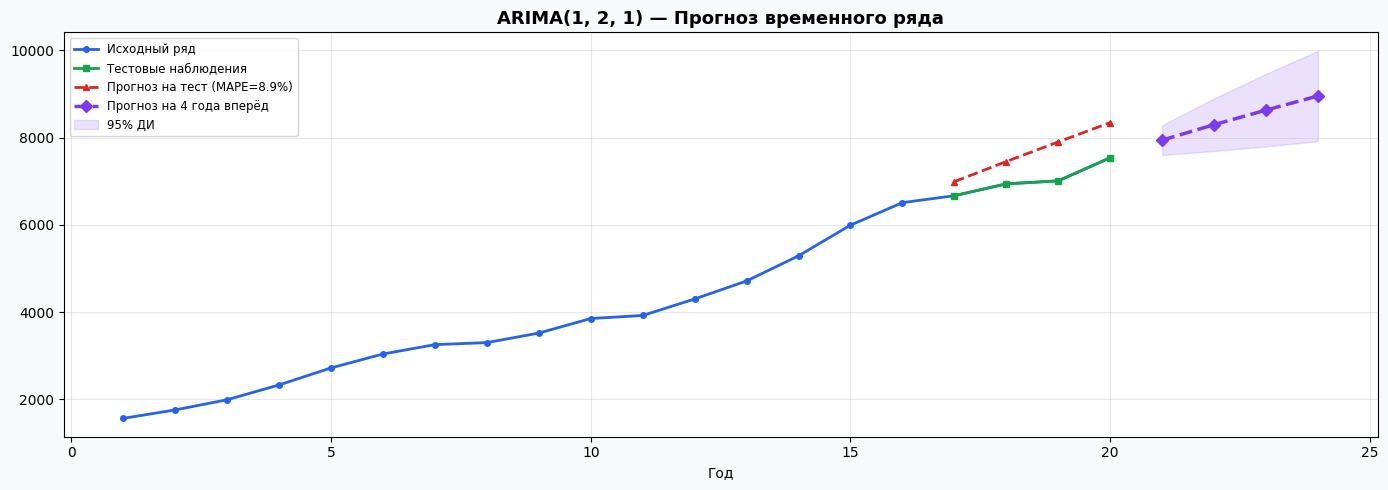

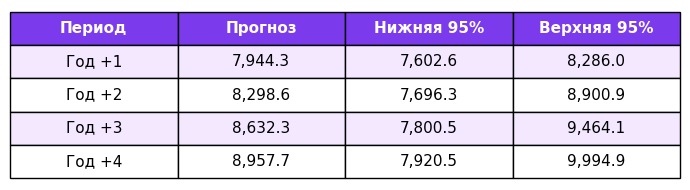

In [90]:
years_hist   = np.arange(1, n + 1)
years_test   = np.arange(n - 3, n + 1)
years_future = np.arange(n + 1, n + 5)

# Основной график
fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')
ax1.set_facecolor('white')
ax1.plot(years_hist, series, color='#2563eb', lw=2, marker='o', ms=4, label='Исходный ряд')
ax1.plot(years_test, test, color='#16a34a', lw=2, marker='s', ms=5, label='Тестовые наблюдения')
ax1.plot(years_test, fc_test, color='#dc2626', lw=2, ls='--', marker='^', ms=5,
         label=f'Прогноз на тест (MAPE={mape:.1f}%)')
ax1.plot(years_future, fc_future, color='#7c3aed', lw=2.5, ls='--', marker='D', ms=6,
         label='Прогноз на 4 года вперёд')
ax1.fill_between(
    years_future,
    fc_ci.iloc[:, 0],
    fc_ci.iloc[:, 1],
    color='#7c3aed',
    alpha=0.15,
    label='95% ДИ'
)
ax1.set_title(f'ARIMA{best_order} — Прогноз временного ряда', fontsize=13, fontweight='bold')
ax1.set_xlabel('Год')
ax1.legend(fontsize=8.5, loc='upper left')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Таблица
fig2, ax2 = plt.subplots(figsize=(7, 2))
ax2.axis('off')
table_data = [
    [
        f'Год +{i+1}',
        f'{fc_future.iloc[i]:,.1f}',
        f'{fc_ci.iloc[i,0]:,.1f}',
        f'{fc_ci.iloc[i,1]:,.1f}'
    ]
    for i in range(4)
]
table = ax2.table(cellText=table_data,
                  colLabels=['Период', 'Прогноз', 'Нижняя 95%', 'Верхняя 95%'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#7c3aed')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#f3e8ff' if r % 2 else 'white')
plt.tight_layout()
plt.show()

### Вывод

После обучения модели была проведена проверка на тестовой выборке. Метрики качества показали следующие результаты:
- MAPE: 8.91%
- MAE:  633.69
- RMSE: 673.72

Полученные значения свидетельствуют о достаточно хорошем качестве прогноза, так как средняя относительная ошибка составляет около 9%, что является приемлемым для задач анализа временных рядов

На заключительном этапе модель была обучена на полном наборе данных и использована для прогнозирования на 4 года вперёд. Полученные значения прогноза:

- 7944.3 (95% ДИ: [7602.6, 8286.0])
- 8298.6 (95% ДИ: [7696.3, 8900.9])
- 8632.3 (95% ДИ: [7800.5, 9464.1])
- 8957.7 (95% ДИ: [7920.5, 9994.9])

## Квартальный ряд

### Загрузка ряда

Длина ряда: 44, среднее: 2622.2, std: 677.4


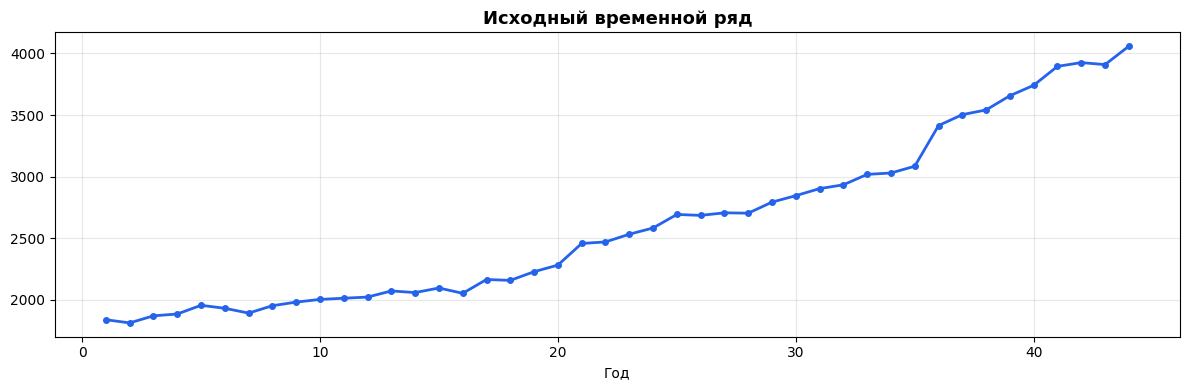

In [91]:
series = quart_df.iloc[14, 6:].dropna().astype(float)
n = len(series)
print(f"Длина ряда: {n}, среднее: {np.mean(series):.1f}, std: {np.std(series):.1f}")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(1, n + 1), series, color='#2563eb', lw=2, marker='o', ms=4)
plt.title('Исходный временной ряд', fontsize=13, fontweight='bold')
plt.xlabel('Год')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Тест на стационарность

Для проверки стационарности используется тест Дики-Фуллера (ADF-test)

**H0:** ряд нестационарен

**H1:** ряд стационарен

----
если **p-value < 0.05** → отвергаем H0 → ряд считается стационарным  
если **p-value ≥ 0.05** → нет оснований отвергнуть H0 → ряд нестационарен 

In [93]:
adf_orig = adfuller(series)
print(f"ADF исходный ряд:    stat={adf_orig[0]:.3f}, p={adf_orig[1]:.4f}")


adf_diff1 = adfuller(np.diff(series, 1))
print(f"ADF 1-я разность:    stat={adf_diff1[0]:.3f}, p={adf_diff1[1]:.4f}")


ADF исходный ряд:    stat=2.394, p=0.9990
ADF 1-я разность:    stat=-6.336, p=0.0000


Видно, что после 1 дифференцирования ряд становится стационарным, таким образом останавливаемся на параметре d = 3

In [94]:
series_diff1 = np.diff(series, n=1)

### ACF/PACF дифференцированного ряда

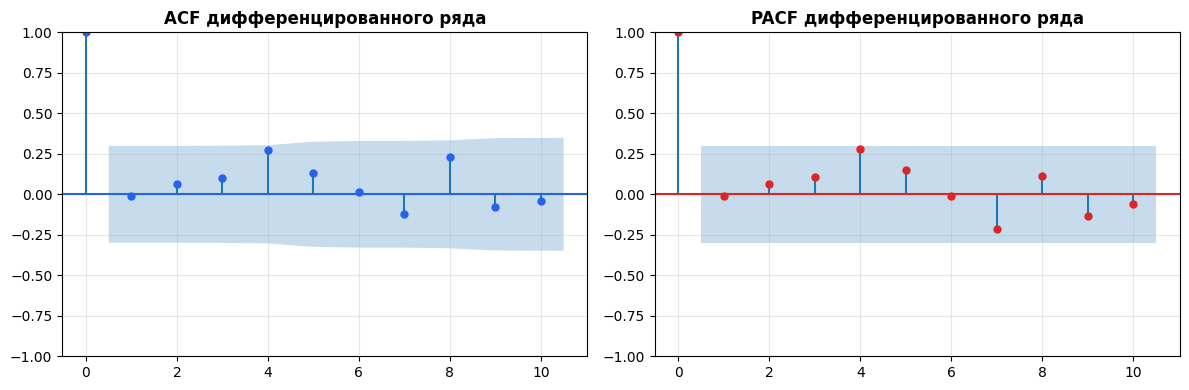

In [95]:
# ACF: если резко обрывается на лаге q → признак MA(q)
# PACF: если резко обрывается на лаге p → признак AR(p)

max_lags = min(10, len(series_diff1) // 2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series_diff1, lags=max_lags, ax=axes[0], color='#2563eb', alpha=0.05)
axes[0].set_title('ACF дифференцированного ряда', fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(series_diff1, lags=max_lags, ax=axes[1], color='#dc2626', alpha=0.05)
axes[1].set_title('PACF дифференцированного ряда', fontweight='bold')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### Подбор параметров

Исходя из теста на стационарность и графиков ACF и PACF можно предположить, что самая лучшая модель будет ARIMA (0,1,0). Однако, учитывая для повышения точности, проверим все близкие модели и выберем лучшую из них по метрике AIC:

- параметр интегрирования d = 1
- параметр авторегрессии p находится в диапазоне [0, 1]
- параметр скользящего среднего q находится в диапазоне [0, 1]

In [96]:
# AIC штрафует за сложность модели, BIC штрафует сильнее
results = []
for p in range(0, 2):
    for d in [1]:
        for q in range(0, 2):
            try:
                m = ARIMA(series, order=(p, d, q)).fit()
                results.append({'order': (p, d, q), 'aic': round(m.aic, 2),
                                 'bic': round(m.bic, 2)})
            except Exception:
                pass

results_df = pd.DataFrame(results).sort_values('aic')
print("Топ-5 моделей")
print(results_df.head(5).to_string(index=False))

Топ-5 моделей
    order    aic    bic
(1, 1, 1) 489.75 495.03
(1, 1, 0) 500.94 504.46
(0, 1, 1) 503.36 506.89
(0, 1, 0) 505.13 506.90


### Проверка остатков (тест Льюнга-Бокса)

Если p > 0.05 — остатки не автокоррелированы → модель адекватна

p для ARIMA(1, 1, 1): 0.4845


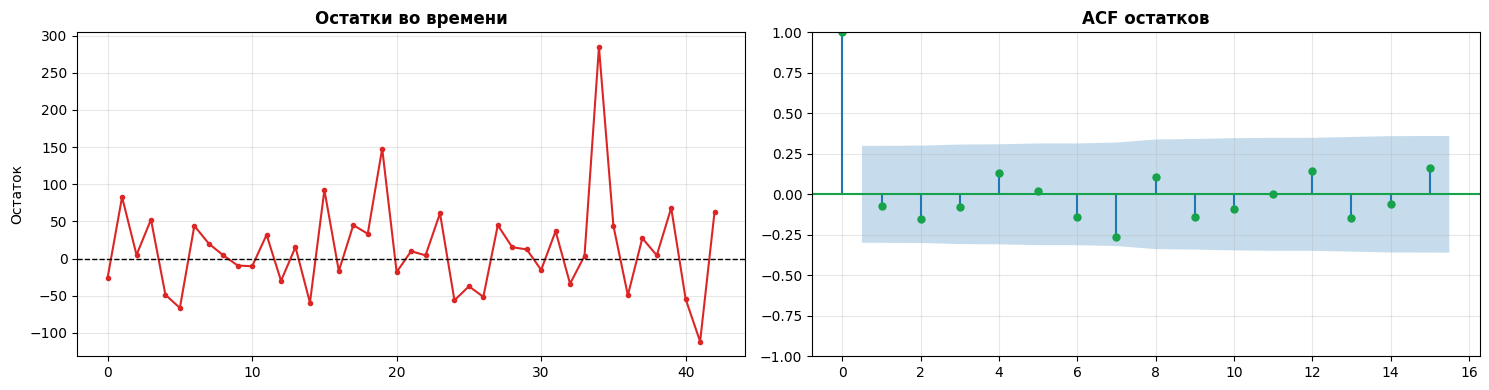

In [97]:
best_order = (1, 1, 1)

model_check = ARIMA(series_diff1, order=best_order).fit()
lb_test = acorr_ljungbox(model_check.resid, lags=[10], return_df=True)
print(f"p для ARIMA{best_order}: {lb_test['lb_pvalue'].values[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Остатки во времени
axes[0].plot(model_check.resid, color='#dc2626', lw=1.5, marker='o', ms=3)
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set_title('Остатки во времени', fontweight='bold')
axes[0].set_ylabel('Остаток')
axes[0].grid(True, alpha=0.3)

# ACF остатков
plot_acf(model_check.resid, lags=15, ax=axes[1], color='#16a34a', alpha=0.05)
axes[1].set_title('ACF остатков', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Тестирование прогноза

Откладываем последние 4 наблюдения как тест и смотрим на метрики

In [98]:
# train/test split
train, test = series[:-4], series[-4:]

# обучение модели
model_train = ARIMA(train, order=best_order).fit()

# прогноз на 4 шага
fc_test = model_train.forecast(steps=4)

# делаем одинаковые индексы
fc_test.index = test.index

# метрики
mape = np.mean(np.abs((test - fc_test) / test)) * 100
mae  = np.mean(np.abs(test - fc_test))
rmse = np.sqrt(mean_squared_error(test, fc_test))

# вывод
print("Тестирование (последние 4 года):")
print(f"Факт:\n{np.round(test, 1)}\n")
print(f"Прогноз:\n{np.round(fc_test, 1)}")

print("\nМетрики качества:")
print(f"MAPE: {mape:.2f}%")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Тестирование (последние 4 года):
Факт:
41    3895.2
42    3925.5
43    3909.4
44    4058.9
Name: 14, dtype: float64

Прогноз:
41    3818.1
42    3894.0
43    3969.0
44    4043.2
Name: predicted_mean, dtype: float64

Метрики качества:
MAPE: 1.17%
MAE:  45.97
RMSE: 51.79


### Финальный прогноз

In [99]:
# обучение на всём ряде
model_full = ARIMA(series, order=best_order).fit()

print("\nИтоговая модель:")
print(model_full.summary())

# прогноз
fc_obj = model_full.get_forecast(steps=4)

fc_future = fc_obj.predicted_mean
fc_ci = fc_obj.conf_int(alpha=0.05)

print("\nПрогноз на 4 года вперёд:")

for i in range(4):
    forecast = fc_future.iloc[i]
    lower = fc_ci.iloc[i, 0]
    upper = fc_ci.iloc[i, 1]

    print(
        f"  Год +{i+1}: "
        f"{forecast:.1f} "
        f"(95% ДИ: [{lower:.1f}, {upper:.1f}])"
    )


Итоговая модель:
                               SARIMAX Results                                
Dep. Variable:                     14   No. Observations:                   44
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -241.874
Date:                Thu, 21 May 2026   AIC                            489.749
Time:                        18:27:18   BIC                            495.033
Sample:                    01-01-1970   HQIC                           491.697
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9907      0.056     17.829      0.000       0.882       1.100
ma.L1         -0.8798      0.210     -4.182      0.000      -1.292      -0.467
sigma2      4366.5949    586.347  

### Визуализация

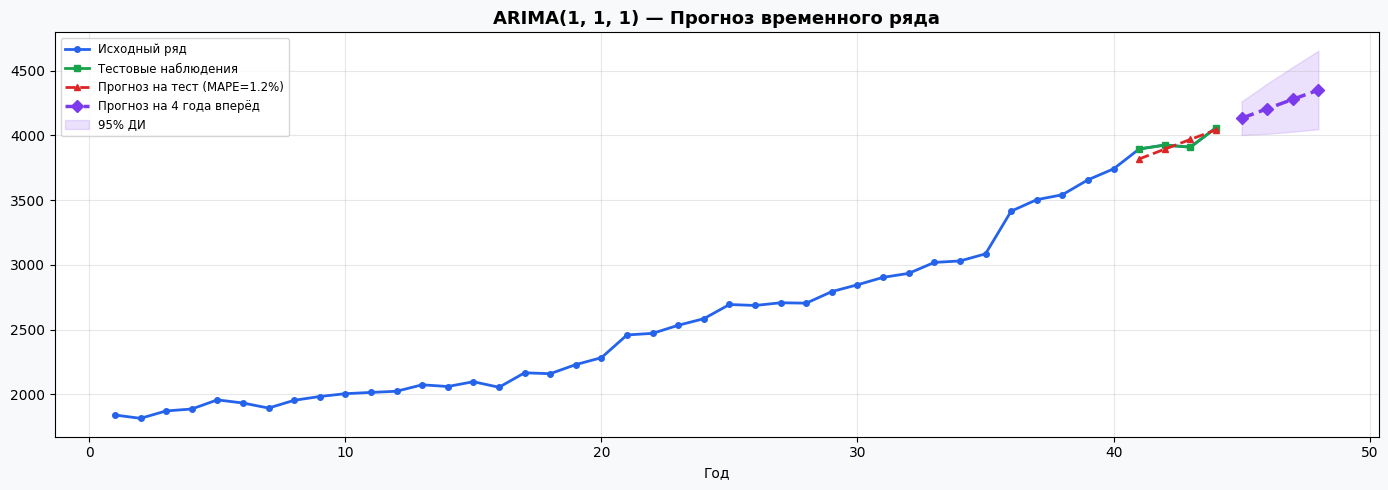

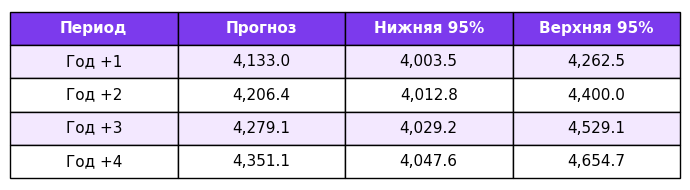

In [100]:
years_hist   = np.arange(1, n + 1)
years_test   = np.arange(n - 3, n + 1)
years_future = np.arange(n + 1, n + 5)

# Основной график
fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')
ax1.set_facecolor('white')
ax1.plot(years_hist, series, color='#2563eb', lw=2, marker='o', ms=4, label='Исходный ряд')
ax1.plot(years_test, test, color='#16a34a', lw=2, marker='s', ms=5, label='Тестовые наблюдения')
ax1.plot(years_test, fc_test, color='#dc2626', lw=2, ls='--', marker='^', ms=5,
         label=f'Прогноз на тест (MAPE={mape:.1f}%)')
ax1.plot(years_future, fc_future, color='#7c3aed', lw=2.5, ls='--', marker='D', ms=6,
         label='Прогноз на 4 года вперёд')
ax1.fill_between(
    years_future,
    fc_ci.iloc[:, 0],
    fc_ci.iloc[:, 1],
    color='#7c3aed',
    alpha=0.15,
    label='95% ДИ'
)
ax1.set_title(f'ARIMA{best_order} — Прогноз временного ряда', fontsize=13, fontweight='bold')
ax1.set_xlabel('Год')
ax1.legend(fontsize=8.5, loc='upper left')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Таблица
fig2, ax2 = plt.subplots(figsize=(7, 2))
ax2.axis('off')
table_data = [
    [
        f'Год +{i+1}',
        f'{fc_future.iloc[i]:,.1f}',
        f'{fc_ci.iloc[i,0]:,.1f}',
        f'{fc_ci.iloc[i,1]:,.1f}'
    ]
    for i in range(4)
]
table = ax2.table(cellText=table_data,
                  colLabels=['Период', 'Прогноз', 'Нижняя 95%', 'Верхняя 95%'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#7c3aed')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#f3e8ff' if r % 2 else 'white')
plt.tight_layout()
plt.show()

### Вывод

После обучения модели была проведена проверка на тестовой выборке. Метрики качества показали следующие результаты:
- MAPE: 1.17%
- MAE:  45.97
- RMSE: 51.79

Полученные значения свидетельствуют о высоком качестве прогноза на квартальных данных, так как средняя относительная ошибка составляет около 1%, что является очень хорошим результатом

На заключительном этапе модель была обучена на полном наборе данных и использована для прогнозирования на 4 года вперёд. Полученные значения прогноза:

- 4133.0
- 4206.4
- 4279.1
- 4351.1 

## Месячный ряд

### Загрузка ряда

Длина ряда: 69, среднее: 6085.5, std: 2672.0


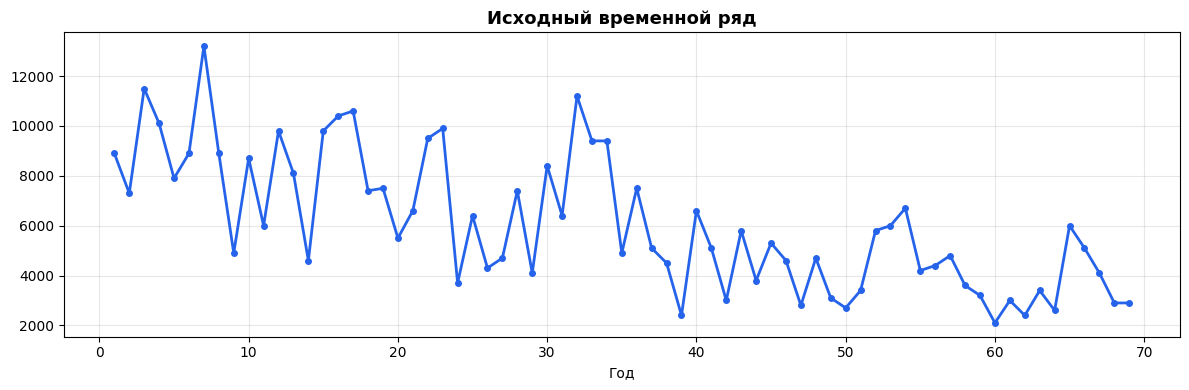

In [137]:
series = month_df.iloc[20, 6:].dropna().astype(float)
n = len(series)
print(f"Длина ряда: {n}, среднее: {np.mean(series):.1f}, std: {np.std(series):.1f}")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(1, n + 1), series, color='#2563eb', lw=2, marker='o', ms=4)
plt.title('Исходный временной ряд', fontsize=13, fontweight='bold')
plt.xlabel('Год')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Тест на стационарность

Для проверки стационарности используется тест Дики-Фуллера (ADF-test)

**H0:** ряд нестационарен

**H1:** ряд стационарен

----
если **p-value < 0.05** → отвергаем H0 → ряд считается стационарным  
если **p-value ≥ 0.05** → нет оснований отвергнуть H0 → ряд нестационарен 

In [138]:
adf_orig = adfuller(series)
print(f"ADF исходный ряд:    stat={adf_orig[0]:.3f}, p={adf_orig[1]:.4f}")


adf_diff1 = adfuller(np.diff(series, 1))
print(f"ADF 1-я разность:    stat={adf_diff1[0]:.3f}, p={adf_diff1[1]:.4f}")

ADF исходный ряд:    stat=-2.651, p=0.0830
ADF 1-я разность:    stat=-13.076, p=0.0000


Видно, что после 1 дифференцирования ряд становится стационарным, таким образом останавливаемся на параметре d = 3

In [139]:
series_diff1 = np.diff(series, n=1)

### ACF/PACF дифференцированного ряда

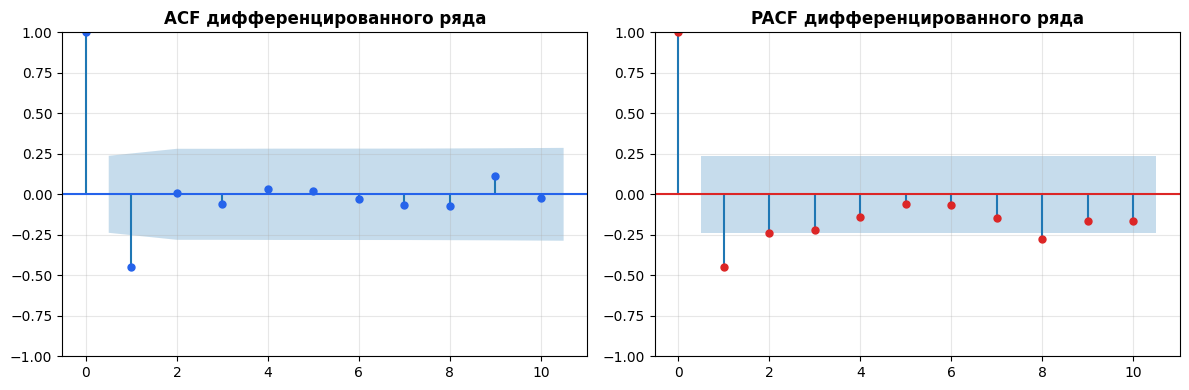

In [140]:
# ACF: если резко обрывается на лаге q → признак MA(q)
# PACF: если резко обрывается на лаге p → признак AR(p)

max_lags = min(10, len(series_diff1) // 2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series_diff1, lags=max_lags, ax=axes[0], color='#2563eb', alpha=0.05)
axes[0].set_title('ACF дифференцированного ряда', fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(series_diff1, lags=max_lags, ax=axes[1], color='#dc2626', alpha=0.05)
axes[1].set_title('PACF дифференцированного ряда', fontweight='bold')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### Подбор параметров

Исходя из теста на стационарность и графиков ACF и PACF можно предположить, что самая лучшая модель будет ARIMA (1,1,1). Однако, учитывая для повышения точности, проверим все близкие модели и выберем лучшую из них по метрике AIC:

In [141]:
# AIC штрафует за сложность модели, BIC штрафует сильнее
results = []
for p in range(1, 3):
    for d in [1]:
        for q in range(1, 3):
            try:
                m = ARIMA(series, order=(p, d, q)).fit()
                results.append({'order': (p, d, q), 'aic': round(m.aic, 2),
                                 'bic': round(m.bic, 2)})
            except Exception:
                pass

results_df = pd.DataFrame(results).sort_values('aic')
print("Топ-5 моделей")
print(results_df.head(5).to_string(index=False))

Топ-5 моделей
    order     aic     bic
(1, 1, 1) 1239.98 1246.64
(2, 1, 1) 1241.00 1249.88
(1, 1, 2) 1241.72 1250.60
(2, 1, 2) 1243.05 1254.15


### Проверка остатков (тест Льюнга-Бокса)

Если p > 0.05 — остатки не автокоррелированы → модель адекватна

p для ARIMA(1, 1, 1): 0.3010


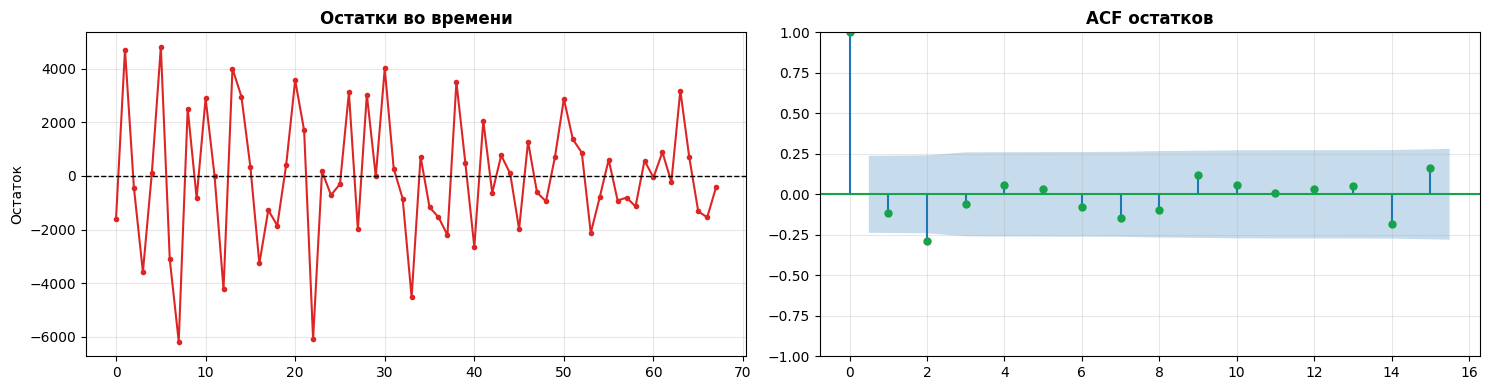

In [142]:
best_order = (1, 1, 1)

model_check = ARIMA(series_diff1, order=best_order).fit()
lb_test = acorr_ljungbox(model_check.resid, lags=[10], return_df=True)
print(f"p для ARIMA{best_order}: {lb_test['lb_pvalue'].values[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Остатки во времени
axes[0].plot(model_check.resid, color='#dc2626', lw=1.5, marker='o', ms=3)
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set_title('Остатки во времени', fontweight='bold')
axes[0].set_ylabel('Остаток')
axes[0].grid(True, alpha=0.3)

# ACF остатков
plot_acf(model_check.resid, lags=15, ax=axes[1], color='#16a34a', alpha=0.05)
axes[1].set_title('ACF остатков', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Тестирование прогноза

Откладываем последние 4 наблюдения как тест и смотрим на метрики

In [143]:
# train/test split
train, test = series[:-4], series[-4:]

# обучение модели
model_train = ARIMA(train, order=best_order).fit()

# прогноз на 4 шага
fc_test = model_train.forecast(steps=4)

# делаем одинаковые индексы
fc_test.index = test.index

# метрики
mape = np.mean(np.abs((test - fc_test) / test)) * 100
mae  = np.mean(np.abs(test - fc_test))
rmse = np.sqrt(mean_squared_error(test, fc_test))

# вывод
print("Тестирование (последние 4 года):")
print(f"Факт:\n{np.round(test, 1)}\n")
print(f"Прогноз:\n{np.round(fc_test, 1)}")

print("\nМетрики качества:")
print(f"MAPE: {mape:.2f}%")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Тестирование (последние 4 года):
Факт:
66    5100.0
67    4100.0
68    2900.0
69    2900.0
Name: 20, dtype: float64

Прогноз:
66    4397.6
67    4050.9
68    3975.8
69    3959.6
Name: predicted_mean, dtype: float64

Метрики качества:
MAPE: 22.15%
MAE:  721.75
RMSE: 833.07


### Финальный прогноз

In [144]:
# обучение на всём ряде
model_full = ARIMA(series, order=best_order).fit()

print("\nИтоговая модель:")
print(model_full.summary())

# прогноз
fc_obj = model_full.get_forecast(steps=4)

fc_future = fc_obj.predicted_mean
fc_ci = fc_obj.conf_int(alpha=0.05)

print("\nПрогноз на 4 года вперёд:")

for i in range(4):
    forecast = fc_future.iloc[i]
    lower = fc_ci.iloc[i, 0]
    upper = fc_ci.iloc[i, 1]

    print(
        f"  Год +{i+1}: "
        f"{forecast:.1f} "
        f"(95% ДИ: [{lower:.1f}, {upper:.1f}])"
    )


Итоговая модель:
                               SARIMAX Results                                
Dep. Variable:                     20   No. Observations:                   69
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -616.991
Date:                Thu, 21 May 2026   AIC                           1239.982
Time:                        18:40:34   BIC                           1246.640
Sample:                    01-01-1970   HQIC                          1242.620
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2259      0.190      1.192      0.233      -0.146       0.597
ma.L1         -0.8522      0.104     -8.225      0.000      -1.055      -0.649
sigma2      4.511e+06   8.56e+05  

### Визуализация

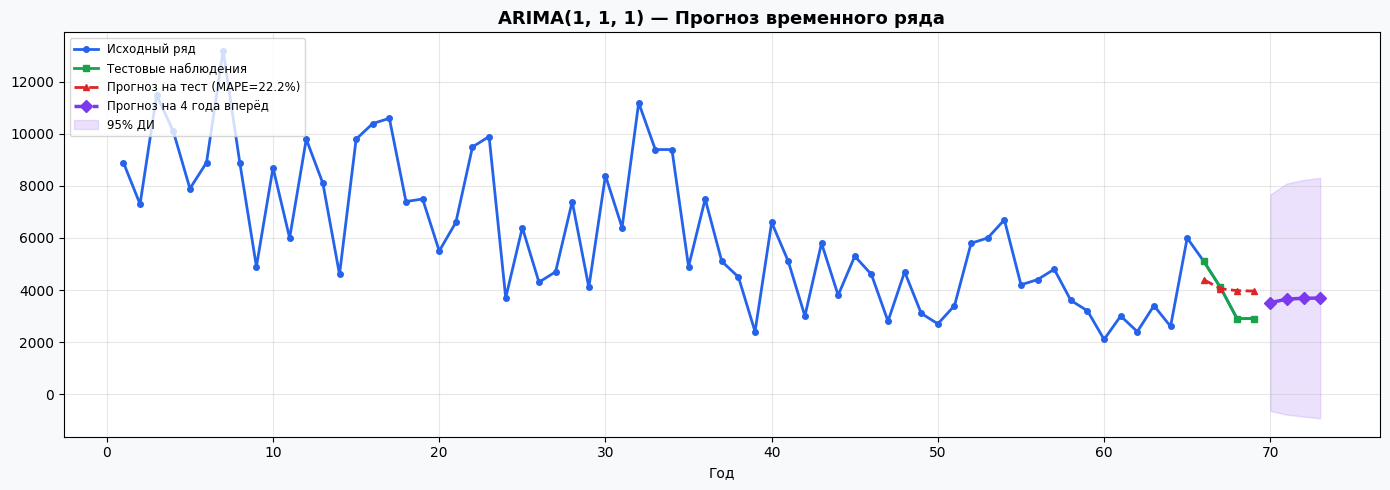

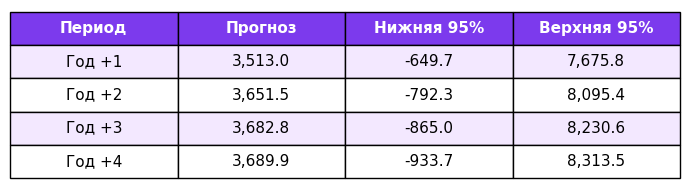

In [145]:
years_hist   = np.arange(1, n + 1)
years_test   = np.arange(n - 3, n + 1)
years_future = np.arange(n + 1, n + 5)

# Основной график
fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')
ax1.set_facecolor('white')
ax1.plot(years_hist, series, color='#2563eb', lw=2, marker='o', ms=4, label='Исходный ряд')
ax1.plot(years_test, test, color='#16a34a', lw=2, marker='s', ms=5, label='Тестовые наблюдения')
ax1.plot(years_test, fc_test, color='#dc2626', lw=2, ls='--', marker='^', ms=5,
         label=f'Прогноз на тест (MAPE={mape:.1f}%)')
ax1.plot(years_future, fc_future, color='#7c3aed', lw=2.5, ls='--', marker='D', ms=6,
         label='Прогноз на 4 года вперёд')
ax1.fill_between(
    years_future,
    fc_ci.iloc[:, 0],
    fc_ci.iloc[:, 1],
    color='#7c3aed',
    alpha=0.15,
    label='95% ДИ'
)
ax1.set_title(f'ARIMA{best_order} — Прогноз временного ряда', fontsize=13, fontweight='bold')
ax1.set_xlabel('Год')
ax1.legend(fontsize=8.5, loc='upper left')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Таблица
fig2, ax2 = plt.subplots(figsize=(7, 2))
ax2.axis('off')
table_data = [
    [
        f'Год +{i+1}',
        f'{fc_future.iloc[i]:,.1f}',
        f'{fc_ci.iloc[i,0]:,.1f}',
        f'{fc_ci.iloc[i,1]:,.1f}'
    ]
    for i in range(4)
]
table = ax2.table(cellText=table_data,
                  colLabels=['Период', 'Прогноз', 'Нижняя 95%', 'Верхняя 95%'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#7c3aed')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#f3e8ff' if r % 2 else 'white')
plt.tight_layout()
plt.show()

### Вывод

После обучения модели была проведена проверка на тестовой выборке. Метрики качества показали следующие результаты:
- MAPE: 22.15%
- MAE:  721.75
- RMSE: 833.07

Построенная модель ARIMA позволяет описывать общую динамику временного ряда, однако точность прогноза является умеренной. Модель может использоваться для общего анализа тенденций и краткосрочного прогнозирования, но результаты следует интерпретировать с осторожностью из-за достаточно высокой относительной ошибки

На заключительном этапе модель была обучена на полном наборе данных и использована для прогнозирования на 4 года вперёд. Полученные значения прогноза:

- 3513.0
- 3651.5
- 3682.8 
- 3689.9

## Общий вывод

В ходе выполнения лабораторной работы были исследованы три различных временных ряда из набора данных M3 Competition и для каждого из них была построена модель ARIMA. На первом этапе выполнялся анализ исходных данных и проверка рядов на стационарность с помощью теста Дики–Фуллера. При необходимости применялось дифференцирование, что позволило определить параметр интегрирования d и привести ряды к стационарному виду.

Далее для каждого ряда был проведён анализ графиков ACF и PACF, на основе которых были получены предварительные оценки параметров p и q. После этого был выполнен перебор нескольких моделей ARIMA с использованием информационного критерия AIC, что позволило выбрать наиболее подходящую конфигурацию модели для каждого временного ряда.

После обучения моделей была проведена оценка качества прогнозирования на тестовых данных с использованием метрик MAE, RMSE и MAPE. Результаты показали, что качество прогнозирования существенно зависит от структуры временного ряда: для некоторых рядов модель продемонстрировала очень высокую точность с минимальной относительной ошибкой, тогда как для других рядов точность оказалась ниже из-за более сложной динамики и колебаний данных.